In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

## 1. Load *Data*

In [6]:
data=pd.read_csv("/content/LoanDataset - LoansDatasest.csv")
data.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


## 2. Data Cleaning
Dropping ID column, checking types, nulls, and duplicates.

In [7]:
data=data.drop(columns="customer_id")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_age         32586 non-null  int64  
 1   customer_income      32586 non-null  object 
 2   home_ownership       32586 non-null  object 
 3   employment_duration  31691 non-null  float64
 4   loan_intent          32586 non-null  object 
 5   loan_grade           32586 non-null  object 
 6   loan_amnt            32585 non-null  object 
 7   loan_int_rate        29470 non-null  float64
 8   term_years           32586 non-null  int64  
 9   historical_default   11849 non-null  object 
 10  cred_hist_length     32586 non-null  int64  
 11  Current_loan_status  32582 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 3.0+ MB


In [9]:
data.describe()

,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,27.732769,4.790161,11.011553,4.761738,5.804026
std,6.360528,4.142746,3.240440,2.471107,4.055078
min,3.000000,0.000000,5.420000,1.000000,2.000000
25%,23.000000,2.000000,7.900000,3.000000,3.000000
50%,26.000000,4.000000,10.990000,4.000000,4.000000
75%,30.000000,7.000000,13.470000,7.000000,8.000000
max,144.000000,123.000000,23.220000,10.000000,30.000000


In [10]:
data.isna().sum()

,0
customer_age,0
customer_income,0
home_ownership,0
employment_duration,895
loan_intent,0
loan_grade,0
loan_amnt,1
loan_int_rate,3116
term_years,0
historical_default,20737


In [11]:
data.duplicated().sum()

np.int64(141)

In [12]:
data.drop_duplicates(inplace=True)

### Some values didn't make sense

Ages and employment durations over 100? Not real. Treating those as missing instead of trusting them.

In [13]:
data["employment_duration"].sort_values(ascending=False).head(20)

,employment_duration
210,123.0
0,123.0
32360,41.0
32520,38.0
32433,34.0
31872,31.0
32268,31.0
31871,31.0
30919,31.0
32567,30.0


In [14]:
data.loc[data["customer_age"] > 100, "customer_age"] = np.nan


In [15]:
data.loc[data["employment_duration"] > 100, "employment_duration"] = np.nan

In [16]:
data[["customer_age", "employment_duration"]].isnull().sum()

,0
customer_age,5
employment_duration,890


In [17]:
data.isna().sum()

,0
customer_age,5
customer_income,0
home_ownership,0
employment_duration,890
loan_intent,0
loan_grade,0
loan_amnt,1
loan_int_rate,3100
term_years,0
historical_default,20625


In [18]:
data["historical_default"].value_counts()

,count
historical_default,
Y,6112
N,5708


In [19]:
data = data.dropna(subset=["Current_loan_status"])

### Numbers stored as text

Loan amount and income had currency symbols and commas stored in as strings

In [20]:
data["loan_amnt"] = (
    data["loan_amnt"]
    .str.replace("£", "")
    .str.replace(",", "")
)

In [21]:
data["loan_amnt"]=data["loan_amnt"].astype(float)

In [22]:
data.loc[
    pd.to_numeric(data["customer_income"], errors="coerce").isna(),
    "customer_income"
]

,customer_income
29164,"250,000"
29358,"103,000"
30727,"164,000"
32337,"45,000"


In [23]:
data["customer_income"]=(data["customer_income"].str.replace(",","").astype(float))

In [24]:
data.describe(include="O")

,home_ownership,loan_intent,loan_grade,historical_default,Current_loan_status
count,32441,32441,32441,11816,32441
unique,4,6,5,2,2
top,RENT,EDUCATION,A,Y,NO DEFAULT
freq,16392,6415,15559,6112,25616


## Exploring the data


Text(0, 0.5, 'No. of customers')

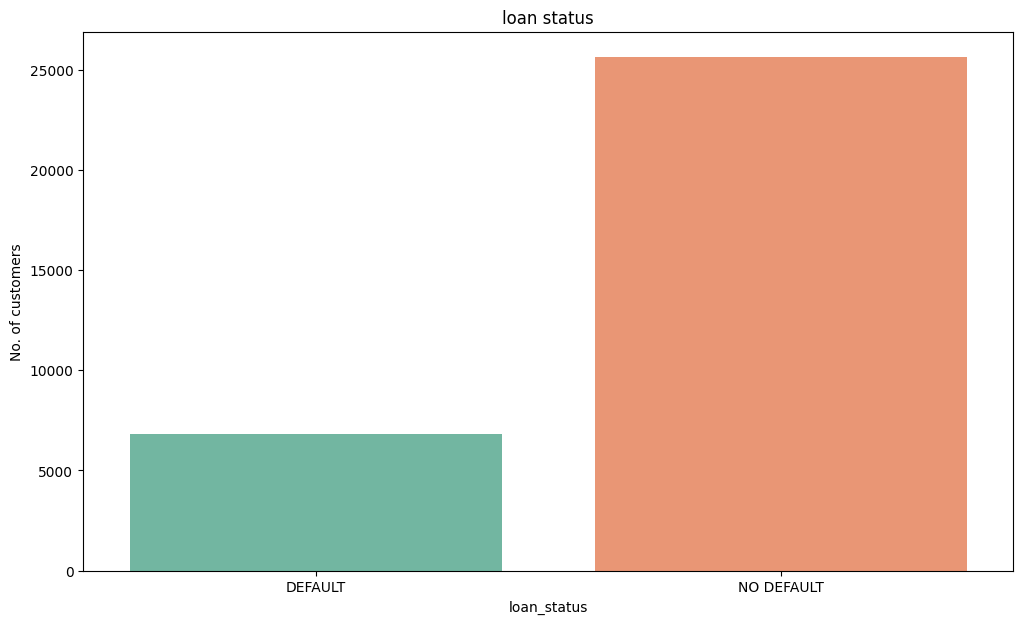

In [25]:
plt.figure(figsize=(12,7))
sns.countplot(
    data=data,
    x="Current_loan_status",
    hue="Current_loan_status",
    palette="Set2",
    legend=False
)
plt.title('loan status')
plt.xlabel("loan_status")
plt.ylabel("No. of customers")

In [26]:
data

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,22.0,59000.0,RENT,NaN,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT
1,21.0,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,NaN,2,NO DEFAULT
2,25.0,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT
3,23.0,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT
4,24.0,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT
...,...,...,...,...,...,...,...,...,...,...,...,...
32581,57.0,53000.0,MORTGAGE,1.0,PERSONAL,C,5800.0,13.16,7,NaN,30,NO DEFAULT
32582,54.0,120000.0,MORTGAGE,4.0,PERSONAL,A,17625.0,7.49,4,NaN,19,NO DEFAULT
32583,65.0,76000.0,RENT,3.0,HOMEIMPROVEMENT,B,35000.0,10.99,5,N,28,DEFAULT
32584,56.0,150000.0,MORTGAGE,5.0,PERSONAL,B,15000.0,11.48,6,NaN,26,NO DEFAULT


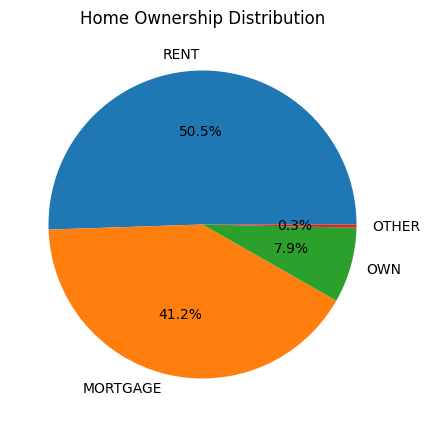

In [27]:
plt.figure(figsize=(5, 5))

data["home_ownership"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
)

plt.title("Home Ownership Distribution")
plt.ylabel("")
plt.show()

<Axes: xlabel='customer_income', ylabel='Count'>

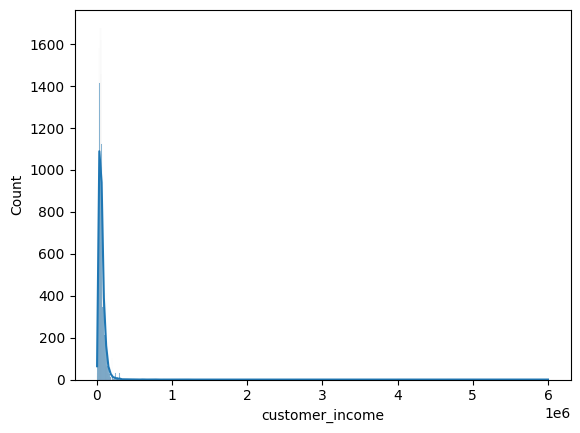

In [28]:
sns.histplot(x=data["customer_income"],kde=True)

<Axes: xlabel='employment_duration', ylabel='Count'>

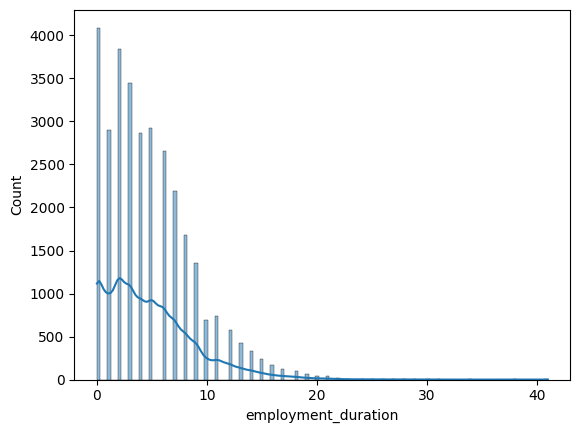

In [29]:
sns.histplot(x=data["employment_duration"],kde=True)

### Checking for outliers

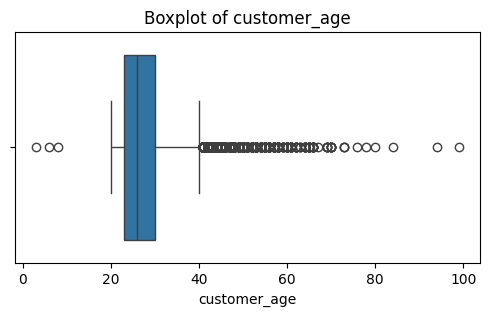

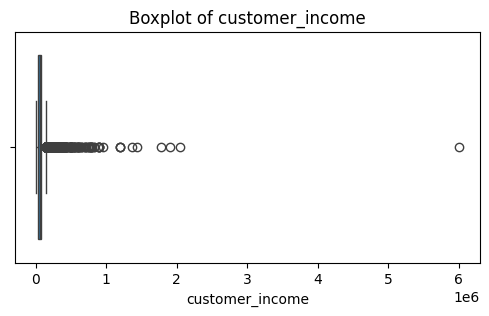

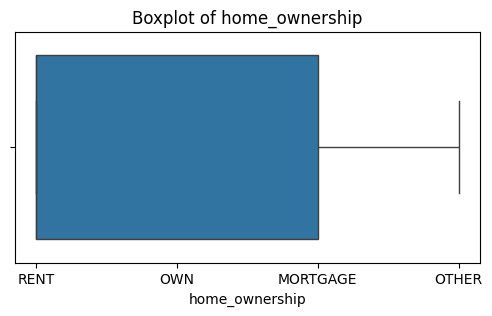

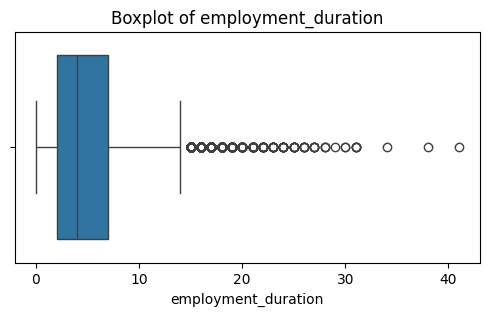

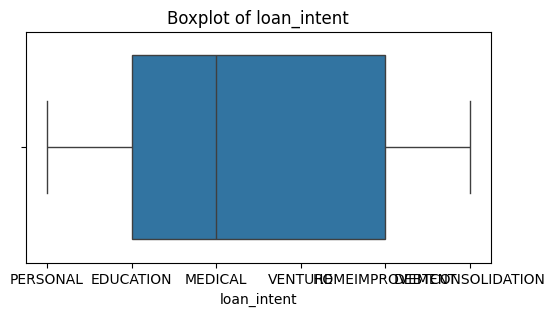

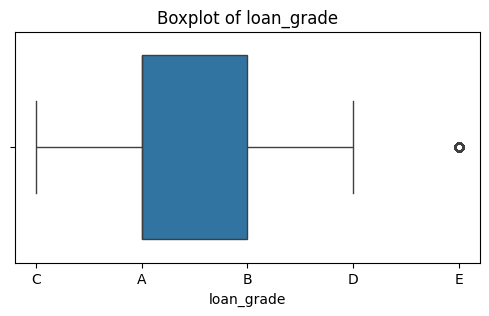

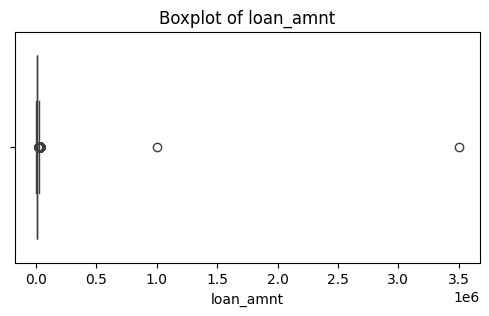

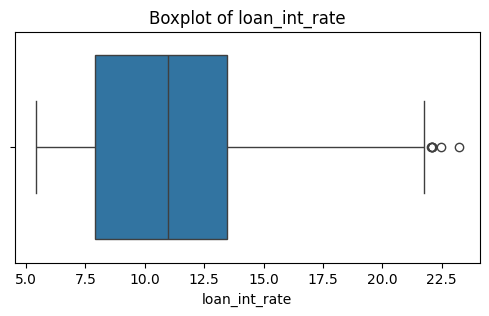

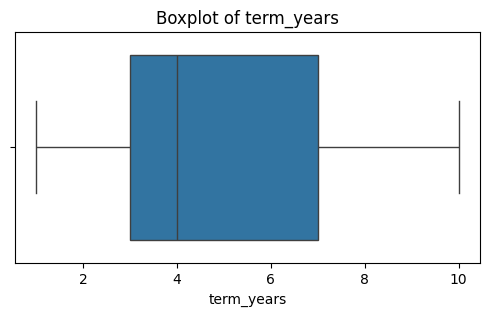

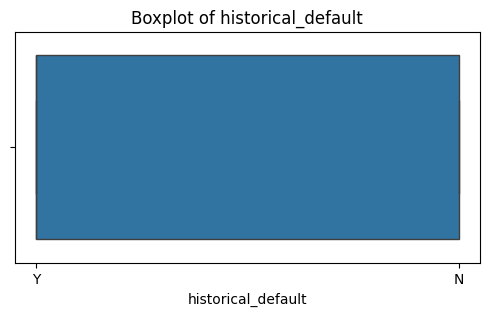

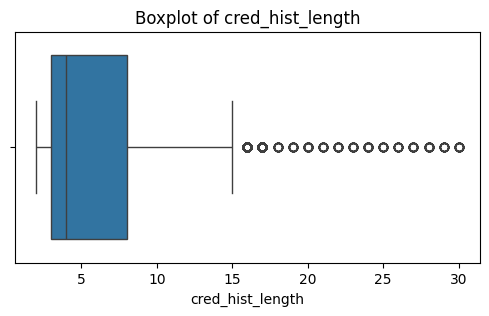

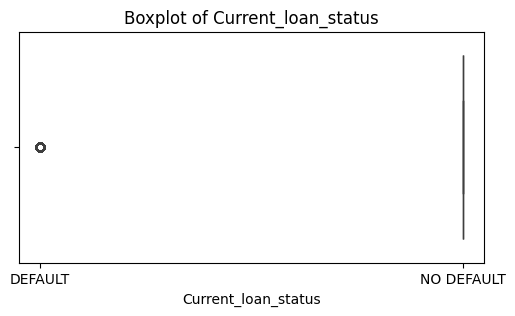

In [30]:
for col in data:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Splitting into train and test

80/20 split, stratified so both sets have the same default rate.

In [31]:
X=data.drop(columns="Current_loan_status",axis=1)
y=data["Current_loan_status"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


## Preprocessing


In [32]:
X_train.isna().sum()

,0
customer_age,4
customer_income,0
home_ownership,0
employment_duration,726
loan_intent,0
loan_grade,0
loan_amnt,1
loan_int_rate,2475
term_years,0
historical_default,16479


In [33]:
num_cols=X_train.select_dtypes(include="number").columns
cat_cols=X_train.select_dtypes(include="object").columns

In [34]:
X_train[num_cols]=X_train[num_cols].fillna(X_train[num_cols].median())

In [35]:
X_test[num_cols]=X_test[num_cols].fillna(X_train[num_cols].median())

In [36]:
X_train[cat_cols]=X_train[cat_cols].fillna("Unknown")
X_test[cat_cols]=X_test[cat_cols].fillna("Unknown")


In [37]:
X_train.describe()

,customer_age,customer_income,employment_duration,loan_amnt,loan_int_rate,term_years,cred_hist_length
count,25952.000000,2.595200e+04,25952.000000,25952.000000,25952.000000,25952.000000,25952.000000
mean,27.725301,6.604494e+04,4.757244,9647.711159,11.009652,4.766993,5.804909
std,6.206933,6.338282e+04,3.972598,8827.480140,3.078089,2.477271,4.047554
min,3.000000,4.200000e+03,0.000000,500.000000,5.420000,1.000000,2.000000
25%,23.000000,3.888450e+04,2.000000,5000.000000,8.490000,3.000000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,4.000000,4.000000
75%,30.000000,7.905000e+04,7.000000,12250.000000,13.110000,7.000000,8.000000
max,94.000000,6.000000e+06,41.000000,1000000.000000,23.220000,10.000000,30.000000


### Capping extreme outliers


In [38]:
X_train.loc[X_train["customer_income"] == X_train["customer_income"].max()]

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length
32302,26.0,6000000.0,MORTGAGE,12.0,PERSONAL,C,5000.0,12.73,4,N,25


In [39]:
X_train.loc[X_train["loan_amnt"] == X_train["loan_amnt"].max()]

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length
322,25.0,120000.0,RENT,6.0,MEDICAL,A,1000000.0,10.74,10,N,2


In [40]:
Q1=X_train["customer_income"].quantile(0.25)
Q3=X_train["customer_income"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR


In [41]:
X_train["customer_income"]=X_train["customer_income"].clip(lower_bound,upper_bound)

In [42]:
X_test["customer_income"]=X_test["customer_income"].clip(lower_bound,upper_bound)

In [43]:
Q1 = X_train["loan_amnt"].quantile(0.25)
Q3 = X_train["loan_amnt"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [44]:
X_train["loan_amnt"]=X_train["loan_amnt"].clip(lower_bound,upper_bound)

In [45]:
X_test["loan_amnt"]=X_test["loan_amnt"].clip(lower_bound,upper_bound)

### Encoding categories


In [46]:
X_train[cat_cols].nunique()

,0
home_ownership,4
loan_intent,6
loan_grade,5
historical_default,3


In [47]:
encoder=OneHotEncoder(handle_unknown="ignore")
X_train_encoded=encoder.fit_transform(X_train[cat_cols])
X_test_encoded=encoder.transform(X_test[cat_cols])

In [48]:
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

In [49]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_num, X_train_encoded])
X_test_final = hstack([X_test_num, X_test_encoded])

In [50]:
print(X_train_final.shape)
print(X_test_final.shape)

(25952, 25)
(6489, 25)


## First model — a baseline tree


In [51]:
tree=DecisionTreeClassifier(max_depth=10)

In [52]:
tree.fit(X_train_final,y_train)

DecisionTreeClassifier(max_depth=10)

In [53]:
y_predict=tree.predict(X_test_final)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_predict))
print(classification_report(y_test, y_predict))

Accuracy: 0.9677916474032979
              precision    recall  f1-score   support

     DEFAULT       0.95      0.89      0.92      1365
  NO DEFAULT       0.97      0.99      0.98      5124

    accuracy                           0.97      6489
   macro avg       0.96      0.94      0.95      6489
weighted avg       0.97      0.97      0.97      6489



In [55]:
print("Train accuracy:", tree.score(X_train_final, y_train))
print("Test accuracy:", tree.score(X_test_final, y_test))

Train accuracy: 0.9746840320591862
Test accuracy: 0.9677916474032979


## Tuning it


In [56]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

In [57]:
from sklearn.metrics import make_scorer, f1_score

f1_default = make_scorer(
    f1_score,
    pos_label="DEFAULT"
)

In [58]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=f1_default,
    n_jobs=-1
)

grid.fit(X_train_final, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, 15, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=DEFAULT))

In [59]:
print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV F1: 0.9075363003239925


In [60]:
best_dt = grid.best_estimator_

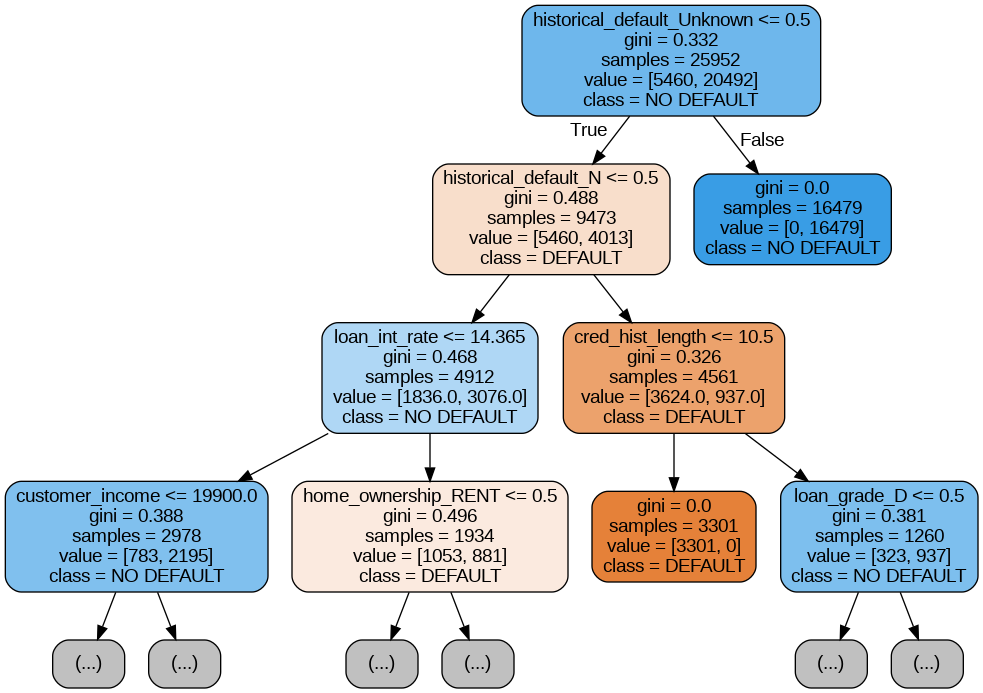

In [105]:
from sklearn.tree import export_graphviz
export_graphviz(
    best_dt,
    out_file="decision_tree_view.dot",
    feature_names=feature_names,
    class_names=best_dt.classes_,
    rounded=True,
    filled=True,
    max_depth=3
)

!dot -Tpng decision_tree_view.dot -o decision_tree_view.png
Image(filename='decision_tree_view.png')

## Evaluation

In [61]:
y_pred = best_dt.predict(X_test_final)

In [62]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1216  149]
 [  59 5065]]


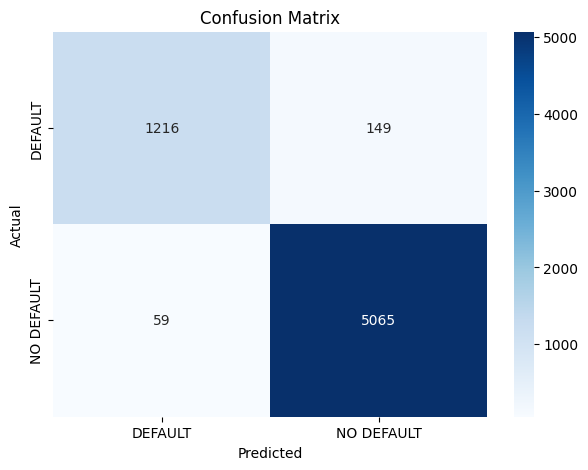

In [63]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["DEFAULT", "NO DEFAULT"],
    yticklabels=["DEFAULT", "NO DEFAULT"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

/tmp/ipykernel_1664/2325747108.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="importance", y="feature", palette="viridis")


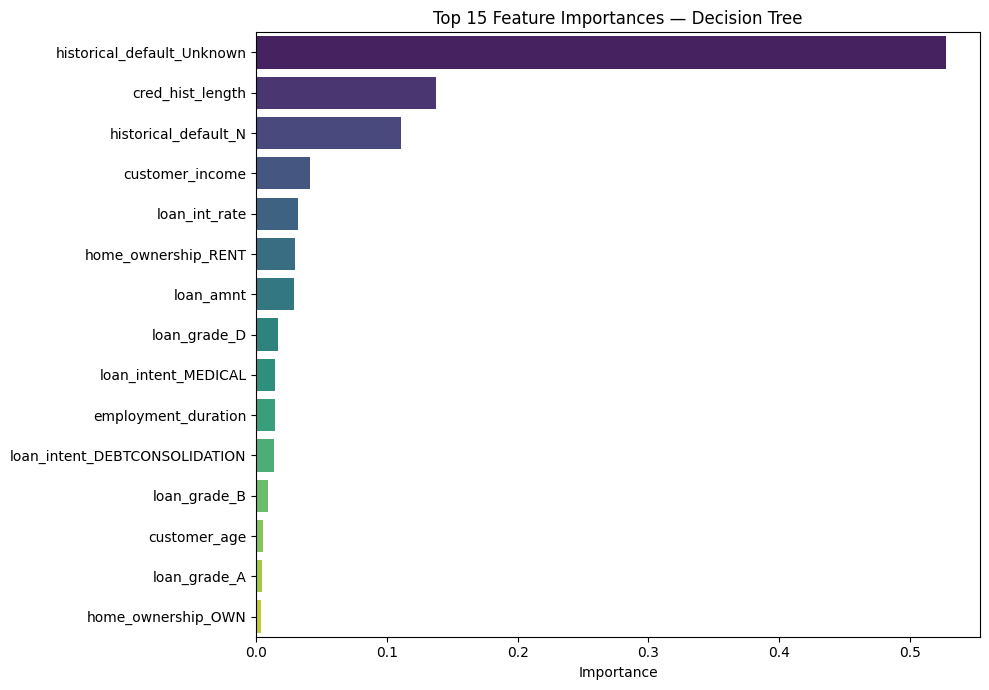

In [64]:

feature_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))

importances = best_dt.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Saving the model


In [65]:
import joblib

joblib.dump(best_dt, "best_decision_tree.pkl")

['best_decision_tree.pkl']

In [66]:
joblib.dump(encoder, "onehot_encoder.pkl")

['onehot_encoder.pkl']

In [85]:
!pip install -r requirements.txt -q
!npm install -g localtunnel -q

ERROR: Operation cancelled by user
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 1s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [86]:
!ls

 app.py				    logs.txt		 sample_data
 best_decision_tree.pkl		    onehot_encoder.pkl
'LoanDataset - LoansDatasest.csv'   requirements.txt


In [87]:
!streamlit run app.py &>/content/logs.txt &

In [88]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://sharp-glasses-run.loca.lt
^C


In [76]:
!wget -q -O - ipv4.icanhazip.com

34.125.209.97
